In [4]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#Load Data
df = pd.read_csv("customer_churn_data.csv")

print(df.shape)
df.head()
print(df.info())


(5880, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5880 non-null   object 
 1   gender            5880 non-null   object 
 2   SeniorCitizen     5880 non-null   int64  
 3   Partner           5880 non-null   object 
 4   Dependents        5880 non-null   object 
 5   tenure            5880 non-null   int64  
 6   PhoneService      5880 non-null   object 
 7   MultipleLines     5880 non-null   object 
 8   InternetService   5880 non-null   object 
 9   OnlineSecurity    5880 non-null   object 
 10  OnlineBackup      5880 non-null   object 
 11  DeviceProtection  5880 non-null   object 
 12  TechSupport       5880 non-null   object 
 13  StreamingTV       5880 non-null   object 
 14  StreamingMovies   5880 non-null   object 
 15  Contract          5880 non-null   object 
 16  PaperlessBilling  5880 non-null

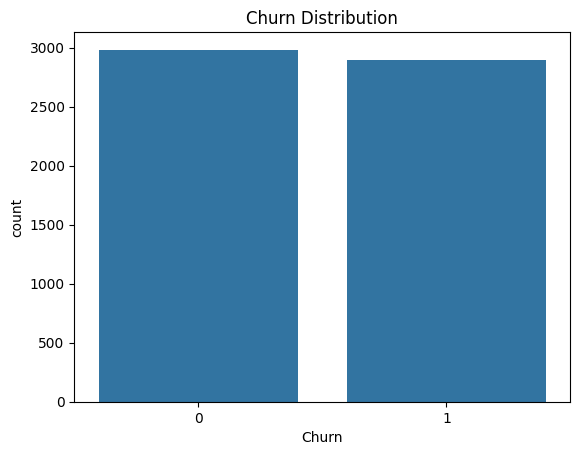

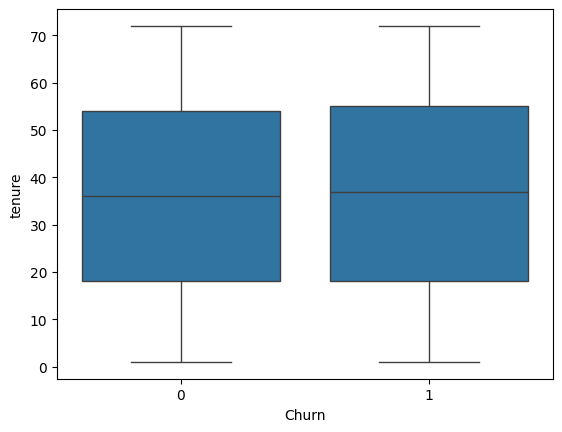

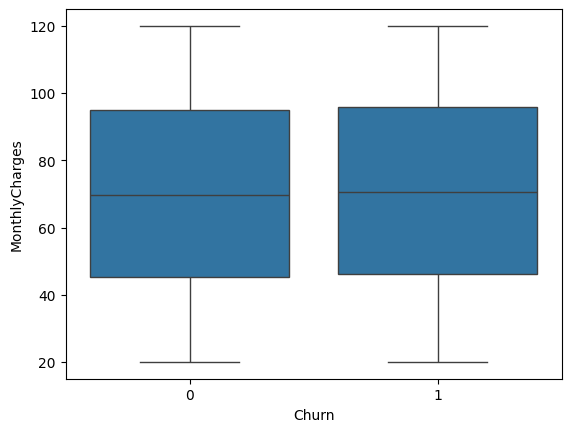

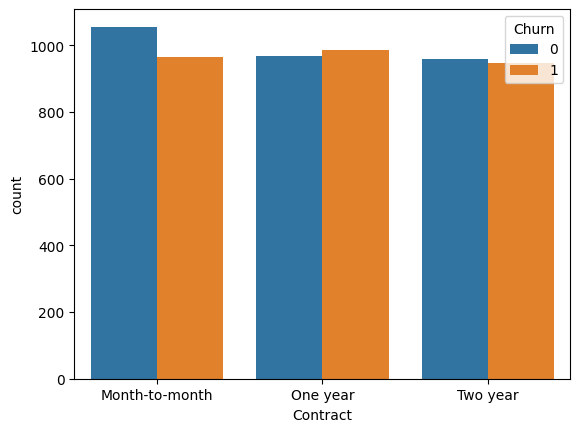

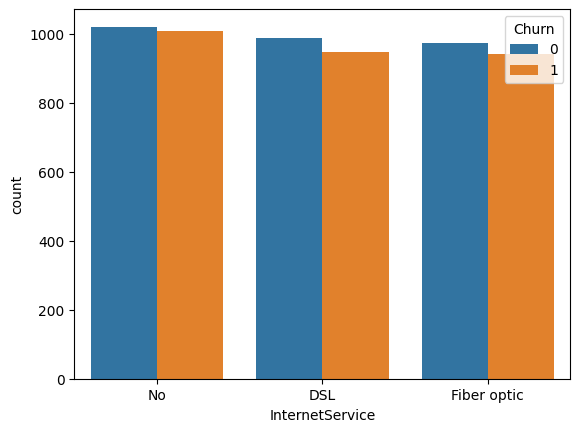

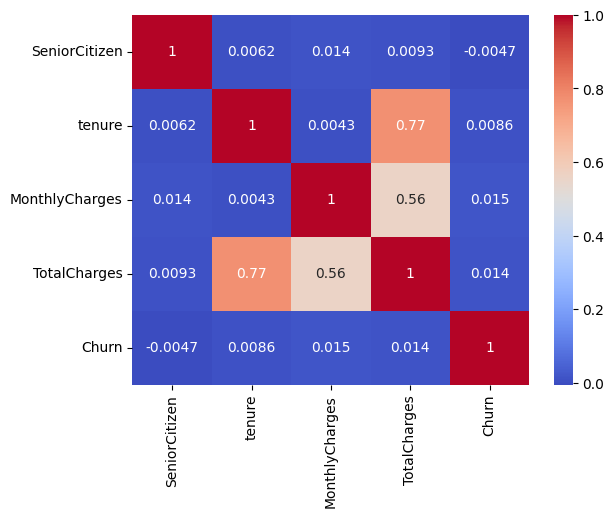

In [5]:
# Convert TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Target encoding
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Churn distribution
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

# Tenure vs churn
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

# MonthlyCharges vs churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

# Contract vs churn
sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

# InternetService vs churn
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.show()

# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

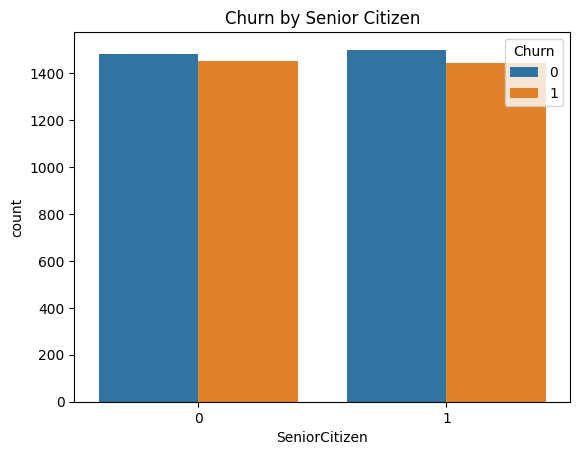

SeniorCitizen
0    0.495232
1    0.490489
Name: Churn, dtype: float64


In [6]:
#EDA
#Do Senior Citizens churn more?
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)
plt.title("Churn by Senior Citizen")
plt.show()

# Percentage view
senior_churn = df.groupby("SeniorCitizen")["Churn"].mean()
print(senior_churn)

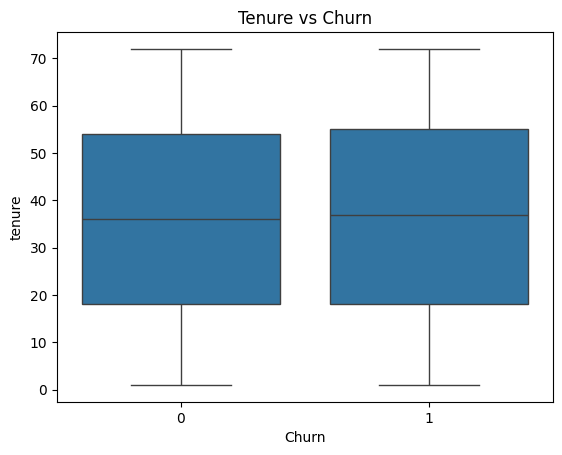

Churn
0    36.371898
1    36.731539
Name: tenure, dtype: float64


In [7]:
#How does tenure affect churn?
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

# Average tenure
print(df.groupby("Churn")["tenure"].mean())

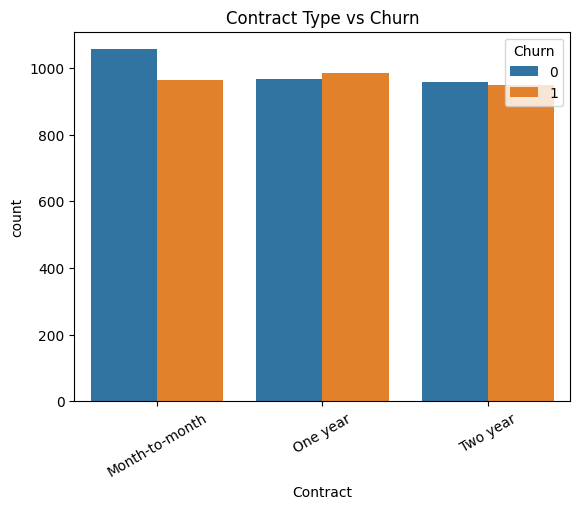

Contract
Month-to-month    0.477228
One year          0.504606
Two year          0.497377
Name: Churn, dtype: float64


In [8]:
#Which contract types have the highest churn?
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=30)
plt.title("Contract Type vs Churn")
plt.show()

# Percentage churn
contract_churn = df.groupby("Contract")["Churn"].mean()
print(contract_churn)

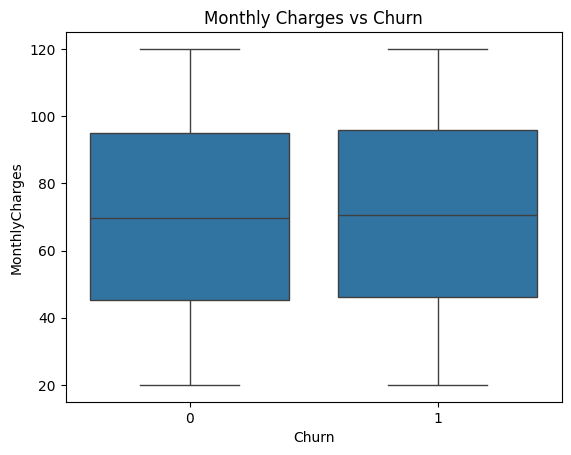

Churn
0    69.732763
1    70.595114
Name: MonthlyCharges, dtype: float64


In [9]:
#Does monthly billing amount influence churn?
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

print(df.groupby("Churn")["MonthlyCharges"].mean())

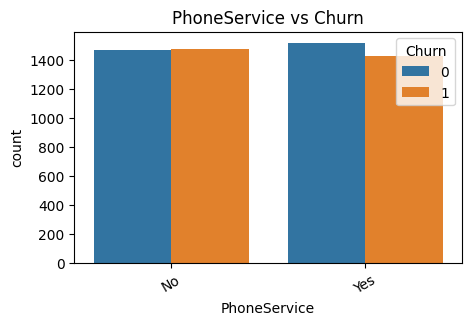

PhoneService
No     0.501871
Yes    0.483849
Name: Churn, dtype: float64




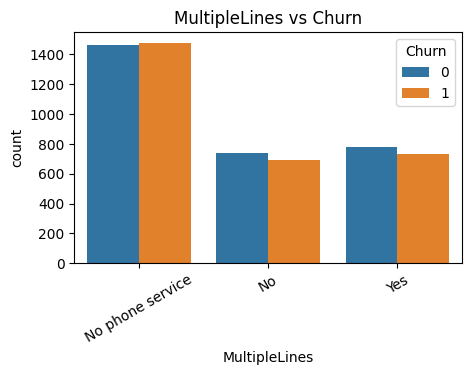

MultipleLines
No                  0.484255
No phone service    0.501871
Yes                 0.483466
Name: Churn, dtype: float64




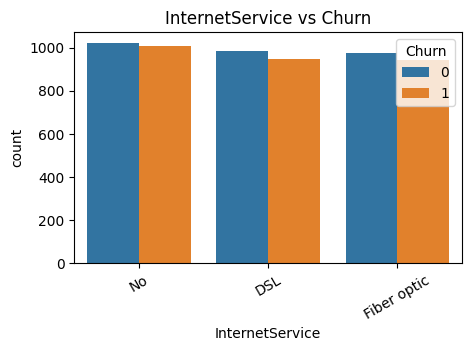

InternetService
DSL            0.490186
Fiber optic    0.491384
No             0.496796
Name: Churn, dtype: float64




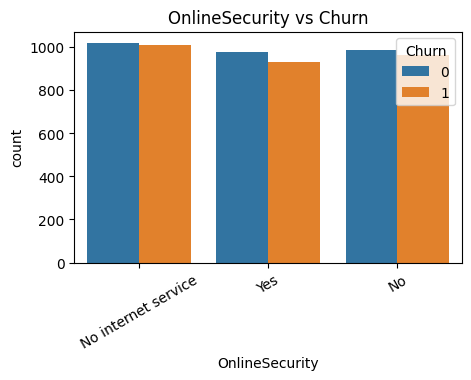

OnlineSecurity
No                     0.493580
No internet service    0.496796
Yes                    0.487920
Name: Churn, dtype: float64




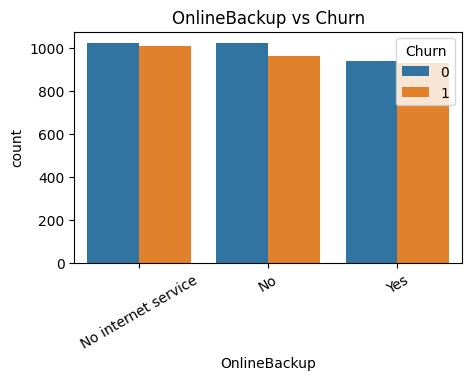

OnlineBackup
No                     0.484391
No internet service    0.496796
Yes                    0.497587
Name: Churn, dtype: float64




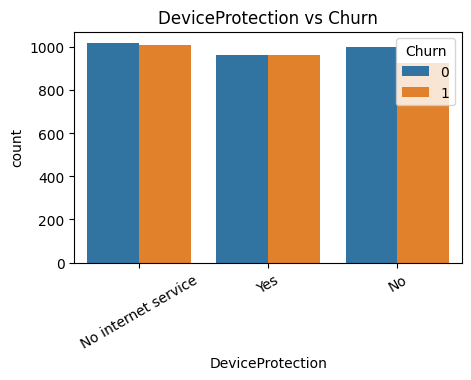

DeviceProtection
No                     0.480519
No internet service    0.496796
Yes                    0.501038
Name: Churn, dtype: float64




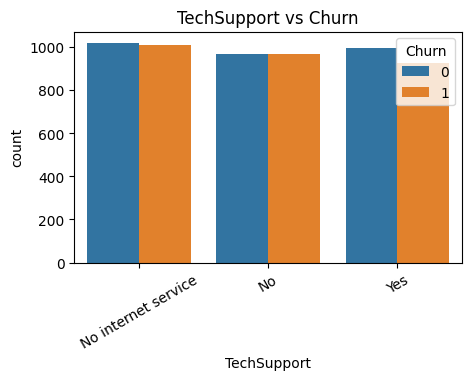

TechSupport
No                     0.500000
No internet service    0.496796
Yes                    0.481501
Name: Churn, dtype: float64




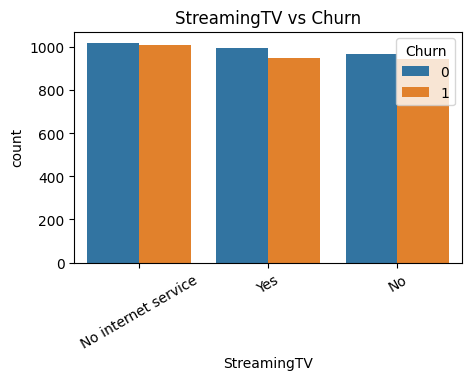

StreamingTV
No                     0.493976
No internet service    0.496796
Yes                    0.487642
Name: Churn, dtype: float64




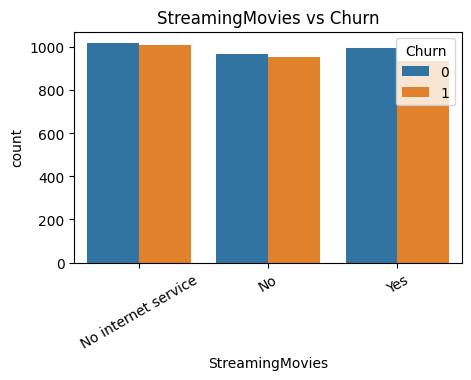

StreamingMovies
No                     0.496875
No internet service    0.496796
Yes                    0.484723
Name: Churn, dtype: float64




In [10]:
#Which services are associated with higher churn?
services = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

for service in services:
    plt.figure(figsize=(5,3))
    sns.countplot(x=service, hue="Churn", data=df)
    plt.title(f"{service} vs Churn")
    plt.xticks(rotation=30)
    plt.show()

    print(df.groupby(service)["Churn"].mean())
    print("\n")

In [11]:
#Data preprocessing
from sklearn.preprocessing import StandardScaler

def preprocess_data(df):
    
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df.fillna(0, inplace=True)

    df.drop("customerID", axis=1, inplace=True)

    # Target
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

    # Encoding
    df = pd.get_dummies(df, drop_first=True)

    # Scaling
    scaler = StandardScaler()
    num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
    df[num_cols] = scaler.fit_transform(df[num_cols])

    return df, scaler

In [12]:
#Feature Engineering
def feature_engineering(df):

    # Avoid division by zero
    df["AvgMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)

    # Tenure buckets
    def tenure_bucket(x):
        if x < 12:
            return "New"
        elif x < 48:
            return "Medium"
        else:
            return "Loyal"

    df["TenureGroup"] = df["tenure"].apply(tenure_bucket)

    # Service count
    services = [
        "PhoneService", "MultipleLines", "InternetService",
        "OnlineSecurity", "OnlineBackup", "DeviceProtection",
        "TechSupport", "StreamingTV", "StreamingMovies"
    ]

    df["ServiceCount"] = df[services].apply(lambda x: sum(x == "Yes"), axis=1)

    return df

In [16]:
#Model Training
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import os
import joblib

def preprocess_data(df):
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df.fillna(0, inplace=True)
    df.drop("customerID", axis=1, inplace=True)
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
    df = pd.get_dummies(df, drop_first=True)
    return df

def feature_engineering(df):
    df["AvgMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)
    return df

df = pd.read_csv("customer_churn_data.csv")

print(df.info())

df = feature_engineering(df)
df = preprocess_data(df)

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(class_weight="balanced")
model.fit(X_train, y_train)

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/model.pkl")
joblib.dump(X.columns.tolist(), "models/columns.pkl")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5880 non-null   object 
 1   gender            5880 non-null   object 
 2   SeniorCitizen     5880 non-null   int64  
 3   Partner           5880 non-null   object 
 4   Dependents        5880 non-null   object 
 5   tenure            5880 non-null   int64  
 6   PhoneService      5880 non-null   object 
 7   MultipleLines     5880 non-null   object 
 8   InternetService   5880 non-null   object 
 9   OnlineSecurity    5880 non-null   object 
 10  OnlineBackup      5880 non-null   object 
 11  DeviceProtection  5880 non-null   object 
 12  TechSupport       5880 non-null   object 
 13  StreamingTV       5880 non-null   object 
 14  StreamingMovies   5880 non-null   object 
 15  Contract          5880 non-null   object 
 16  PaperlessBilling  5880 non-null   object 


['models/columns.pkl']

In [37]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier


X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}


try:
    models["XGBoost"] = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
except:
    print("XGBoost not available")


results = []

for name, model in models.items():
    print(f"\n🔹 Training {name}...\n")

    try:
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        roc = roc_auc_score(y_test, y_prob)

        print("ROC-AUC:", round(roc, 3))
        print(classification_report(y_test, y_pred))

        results.append({
            "Model": name,
            "ROC-AUC": roc
        })

    except Exception as e:
        print(f"{name} failed:", e)


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

print("\n📊 Model Comparison:")
display(results_df)


best_model_name = results_df.iloc[0]["Model"]
print("\n🏆 Best Model:", best_model_name)

best_model = models[best_model_name]


🔹 Training Logistic Regression...



c:\Users\IBuild\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ROC-AUC: 0.47
              precision    recall  f1-score   support

           0       0.47      0.46      0.47       596
           1       0.46      0.48      0.47       580

    accuracy                           0.47      1176
   macro avg       0.47      0.47      0.47      1176
weighted avg       0.47      0.47      0.47      1176


🔹 Training Random Forest...

ROC-AUC: 0.498
              precision    recall  f1-score   support

           0       0.50      0.55      0.53       596
           1       0.49      0.44      0.46       580

    accuracy                           0.50      1176
   macro avg       0.50      0.50      0.50      1176
weighted avg       0.50      0.50      0.50      1176


🔹 Training Gradient Boosting...

ROC-AUC: 0.461
              precision    recall  f1-score   support

           0       0.49      0.52      0.50       596
           1       0.47      0.44      0.46       580

    accuracy                           0.48      1176
   macro avg       0

,Model,ROC-AUC
1,Random Forest,0.498039
3,XGBoost,0.484778
0,Logistic Regression,0.470363
2,Gradient Boosting,0.461149



🏆 Best Model: Random Forest


In [ ]:
#Model Evaluation
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

def evaluate(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    

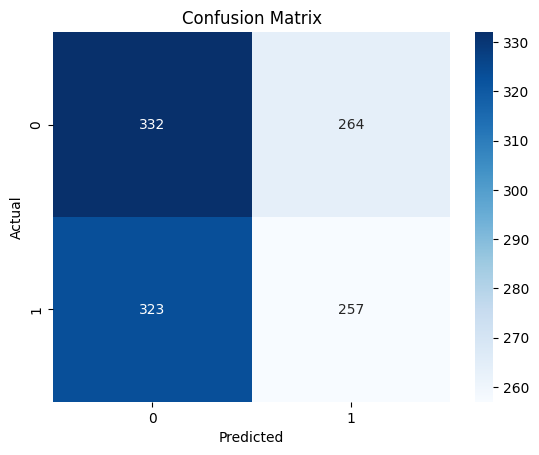

In [21]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    # Classification report as dataframe
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    print("📊 Classification Report:")
    display(report_df)

    # ROC-AUC
    print("\n🎯 ROC-AUC Score:", roc_auc_score(y_test, y_prob))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, 
                         index=["Actual No", "Actual Yes"],
                         columns=["Predicted No", "Predicted Yes"])
    
    print("\n📉 Confusion Matrix:")
    display(cm_df)

def plot_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
y_pred = model.predict(X_test)
plot_confusion_matrix(y_test, y_pred)

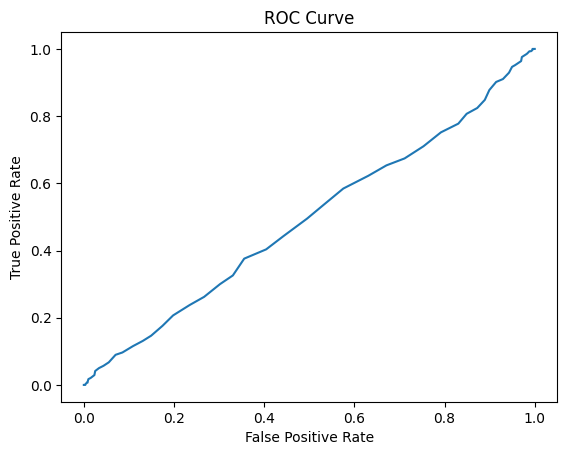

📊 Classification Report:


,precision,recall,f1-score,support
0,0.506870,0.557047,0.530775,596.00000
1,0.493282,0.443103,0.466848,580.00000
accuracy,0.500850,0.500850,0.500850,0.50085
macro avg,0.500076,0.500075,0.498812,1176.00000
weighted avg,0.500169,0.500850,0.499247,1176.00000



🎯 ROC-AUC Score: 0.4918407197408007

📉 Confusion Matrix:


,Predicted No,Predicted Yes
Actual No,332,264
Actual Yes,323,257


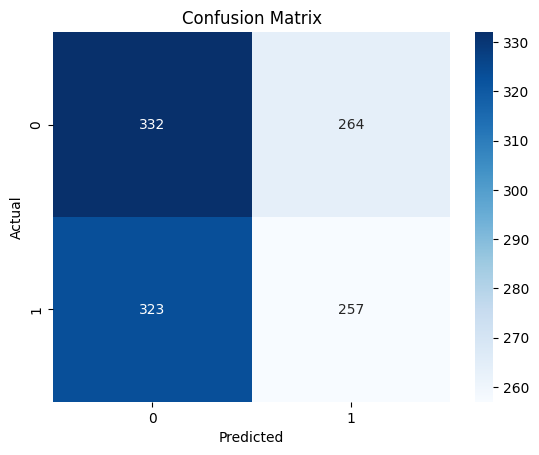

In [24]:
#ROC Curve
from sklearn.metrics import roc_curve

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

evaluate(model, X_test, y_test)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

plot_confusion_matrix(y_test, y_pred)

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc
    })

results_df = pd.DataFrame(results)
display(results_df)

c:\Users\IBuild\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.462312,0.475862,0.468989,0.470363
1,Random Forest,0.490421,0.441379,0.464610,0.498039
2,Gradient Boosting,0.470696,0.443103,0.456483,0.461149
3,XGBoost,0.485320,0.484483,0.484901,0.484778


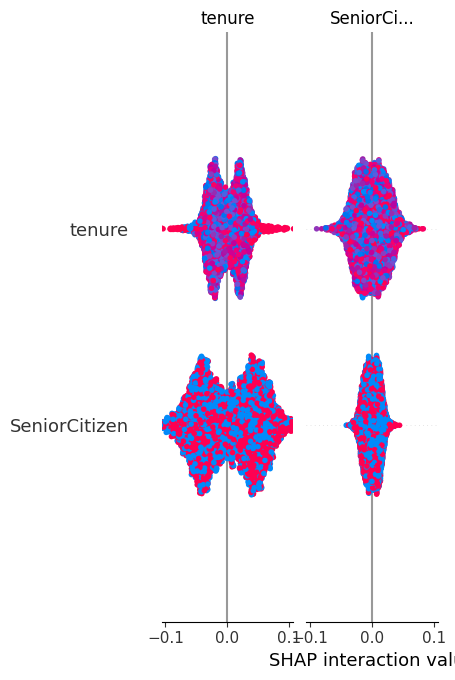

In [31]:
#SHAP Analysis
import shap
import joblib
import pandas as pd


model = joblib.load("models/model.pkl")
columns = joblib.load("models/columns.pkl")   


df = pd.read_csv("customer_churn_data.csv")
def feature_engineering(df):
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df["AvgMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)
    return df


def preprocess_data(df):
    df.fillna(0, inplace=True)
    df.drop("customerID", axis=1, inplace=True)
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
    df = pd.get_dummies(df, drop_first=True)
    return df
df = feature_engineering(df)
df = preprocess_data(df)
X = df.drop("Churn", axis=1)
X = X.reindex(columns=columns, fill_value=0)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X)
else:
    shap.summary_plot(shap_values, X)

,Threshold,Precision,Recall,F1-score
0,0.1,0.490956,0.982759,0.654796
1,0.2,0.483841,0.903448,0.630186
2,0.3,0.485356,0.800000,0.604167
3,0.4,0.481144,0.637931,0.548554
4,0.5,0.485320,0.484483,0.484901
5,0.6,0.505208,0.334483,0.402490
6,0.7,0.466667,0.168966,0.248101
7,0.8,0.439560,0.068966,0.119225


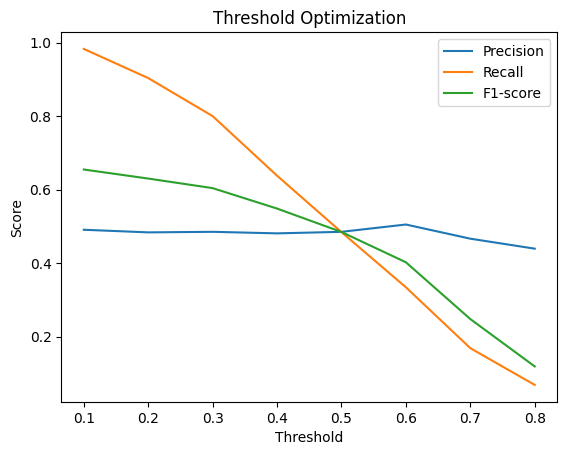

Best Threshold: 0.1


In [39]:
#Threshold Optimization
y_prob = model.predict_proba(X_test)[:, 1]

import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

thresholds = np.arange(0.1, 0.9, 0.1)

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Threshold": t,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

results_df = pd.DataFrame(results)
display(results_df)
plt.plot(results_df["Threshold"], results_df["Precision"], label="Precision")
plt.plot(results_df["Threshold"], results_df["Recall"], label="Recall")
plt.plot(results_df["Threshold"], results_df["F1-score"], label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()
plt.show()

best_row = results_df.loc[results_df["F1-score"].idxmax()]
best_threshold = best_row["Threshold"]

print("Best Threshold:", best_threshold)
y_pred_final = (y_prob >= best_threshold).astype(int)


In [34]:
from fastapi import FastAPI
import pandas as pd
import joblib

app = FastAPI()
model = joblib.load("models/model.pkl")
scaler = joblib.load("models/model.pkl")
columns = joblib.load("models/model.pkl")

@app.get("/")
def home():
    return {"message": "Churn Prediction API Running"}

@app.post("/predict")
def predict(data: dict):

    df = pd.DataFrame([data])

    # Feature engineering
    df["AvgMonthlySpend"] = df["MonthlyCharges"] * df["tenure"]
    df = pd.get_dummies(df)
    df = df.reindex(columns=columns, fill_value=0)
    prob = model.predict_proba(df)[0][1]

    risk = "High" if prob > 0.6 else "Medium" if prob > 0.3 else "Low"

    return {
        "churn_probability": round(prob, 2),
        "churn_risk": risk
    }